In [1]:
import numpy as np
import pandas as pd

In [13]:
%connect_info

{"key":"83e938e6-a6d5-42b3-9aa1-3661932f0785","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9000,"control_port":9001,"shell_port":9002,"stdin_port":9003,"iopub_port":9004,"kernel_name":"python3115jvsc74a57bd0e51a11a35a9cffe10dbeeadb5683ca5855e70b329073972aeeab17b98f2e31e9"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing c:\Users\Ngo_Duc_Phu\AppData\Roaming\jupyter\runtime\kernel-v366b162dcd5ca8713eb9ec6ae6d7abfe293558667.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


In [126]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import pickle

def extract_hourly_features_from_data(data, start_idx, end_idx):
    """
    Build hourly features directly from the raw dataframe
    Independent of any model or scaler
    
    data:      original dataframe with belpex, solar, wind, load
    start_idx: first hour index
    end_idx:   last hour index
    
    Returns:   (n_hours, n_features) array
    """
    all_features = []
    
    for idx in range(start_idx, end_idx):
        # ── Skip if not enough history ──
        if idx < 168:   # need at least 7 days of history
            continue
        
        h = idx % 24   # hour of day (0-23)
        
        # ── Raw values at this hour ──
        solar = data['solar'].iloc[idx]
        wind  = data['wind'].iloc[idx]
        load  = data['load'].iloc[idx]
        price = data['belpex'].iloc[idx]
        
        # ── Today's values (same day, all hours so far) ──
        day_start     = idx - h
        solar_today   = data['solar'].iloc[day_start:idx+1].values
        wind_today    = data['wind'].iloc[day_start:idx+1].values
        load_today    = data['load'].iloc[day_start:idx+1].values
        # prices_today  = data['belpex'].iloc[day_start:idx].values

        # # ── Yesterday same hour ──
        # price_lag24   = data['belpex'].iloc[idx - 24]
        # solar_lag24   = data['solar'].iloc[idx - 24]
        # wind_lag24    = data['wind'].iloc[idx - 24]
        # load_lag24    = data['load'].iloc[idx - 24]

        # # ── Last week same hour ──
        # price_lag168  = data['belpex'].iloc[idx - 168]

        # ── Day of week ──
        dow           = data.index[idx].dayofweek  # 0=Mon, 6=Sun
        is_weekend    = int(dow >= 5)

        features = [
            # Hour identity
            h,
            int(h >= 7  and h <= 9),    # morning peak
            int(h >= 17 and h <= 20),   # evening peak
            int(h >= 22 or  h <= 5),    # night
            dow,
            is_weekend,

            # Solar
            solar,
            solar_today.mean(),
            solar_today.max(),
            solar_lag24,

            # Wind
            wind,
            wind_today.mean(),
            wind_today.max(),
            wind_lag24,

            # Load
            load,
            load_today.mean(),
            load_today.min(),
            load_lag24,

            # # Price history
            # price_lag24,
            # price_lag168,
            # prices_today.mean() if len(prices_today) > 0 else price_lag24,
            # prices_today.min()  if len(prices_today) > 0 else price_lag24,

            # Renewable ratio
            (solar + wind) / (load + 1),
            (solar_today + wind_today).mean() / (load_today.mean() + 1),
        ]
        
        all_features.append(features)
    
    return np.array(all_features)


# feature_names = [
#     'hour_of_day', 'is_morning_peak', 'is_evening_peak',
#     'is_night', 'day_of_week', 'is_weekend',
#     'solar_this_hour', 'avg_solar_today', 'max_solar_today', 'solar_lag24',
#     'wind_this_hour', 'avg_wind_today', 'max_wind_today', 'wind_lag24',
#     'load_this_hour', 'avg_load_today', 'min_load_today', 'load_lag24',
#     'price_lag24', 'price_lag168',
#     'avg_price_so_far_today', 'min_price_so_far_today',
#     'renewable_ratio_this_hour', 'renewable_ratio_daily'
# ]

# feature_names = [
#     'hour_of_day', 'is_morning_peak', 'is_evening_peak',
#     'is_night', 'day_of_week', 'is_weekend',
#     'solar_this_hour', 'avg_solar_today', 'max_solar_today', 'solar_lag24',
#     'wind_this_hour', 'avg_wind_today', 'max_wind_today', 'wind_lag24',
#     'load_this_hour', 'avg_load_today', 'min_load_today', 'load_lag24',
#     'renewable_ratio_this_hour', 'renewable_ratio_daily'
# ]

feature_names = [
    'hour_of_day', 'is_morning_peak', 'is_evening_peak',
    'is_night', 'day_of_week', 'is_weekend',
    'solar_this_hour', 'avg_solar_today', 'max_solar_today', 'solar_lag24',
    'wind_this_hour', 'avg_wind_today', 'max_wind_today', 'wind_lag24',
    'load_this_hour', 'avg_load_today', 'min_load_today', 'load_lag24',
    'price_lag24', 'price_lag168',
    'renewable_ratio_this_hour', 'renewable_ratio_daily'
]

In [127]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pickle

# ── Load your dataset ──
df = pd.read_csv('Full_Dataset.csv', header=0)
df.rename(columns={'Date': 'time'}, inplace=True)
df['time'] = pd.to_datetime(df['time'], dayfirst=True)
df.set_index('time', inplace=True)
df = df.groupby(level=0).mean()
df = df[['Price_BE', 'Load_FR', 'Gen_FR', 
          'Price_CH', 'Wind_BE', 'Solar_BE', 
          'Load_BE']].resample('1h').mean().ffill()

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (45167, 7)
                     Price_BE  Load_FR   Gen_FR  Price_CH   Wind_BE  Solar_BE  \
time                                                                            
2021-01-01 00:00:00     48.19  64600.0  62414.0     45.94  484.1150       0.0   
2021-01-01 01:00:00     44.68  63700.0  60611.5     44.53  674.8450       0.0   
2021-01-01 02:00:00     42.92  60600.0  58978.0     41.01  419.5400       0.0   
2021-01-01 03:00:00     40.39  58150.0  58519.5     39.23  406.6575       0.0   
2021-01-01 04:00:00     40.20  57450.0  57899.5     38.43  528.6450       0.0   

                       Load_BE  
time                            
2021-01-01 00:00:00  8571.4375  
2021-01-01 01:00:00  8160.9775  
2021-01-01 02:00:00  7827.1225  
2021-01-01 03:00:00  7628.6800  
2021-01-01 04:00:00  7594.3100  


In [130]:
def build_features(df):
    """
    Build hourly features with lag values
    directly from the raw dataframe
    """
    features = pd.DataFrame(index=df.index)

    # ── Time features ──
    features['hour']           = df.index.hour
    features['dayofweek']      = df.index.dayofweek
    features['is_weekend']     = (df.index.dayofweek >= 5).astype(int)
    features['is_morning_peak']= df.index.hour.isin(range(7, 10)).astype(int)
    features['is_evening_peak']= df.index.hour.isin(range(17, 21)).astype(int)
    features['is_night']       = (
        (df.index.hour >= 22) | (df.index.hour <= 5)
    ).astype(int)
    features['month']          = df.index.month

    # ── Belgian features ──
    features['solar_be']       = df['Solar_BE']
    features['wind_be']        = df['Wind_BE']
    features['load_be']        = df['Load_BE']

    # ── French features ──
    features['load_fr']        = df['Load_FR']
    features['gen_fr']         = df['Gen_FR']

    # # ── Swiss price ──
    # features['price_ch']       = df['Price_CH']

    # ── Renewable ratio ──
    features['renewable_ratio']= (
        (df['Solar_BE'] + df['Wind_BE']) / (df['Load_BE'] + 1)
    )
    features['gen_load_ratio_fr'] = df['Gen_FR'] / (df['Load_FR'] + 1)

    # # ── Lag features (previous hours) ──
    # features['price_be_lag1']  = df['Price_BE'].shift(1)   # 1h ago
    features['price_be_lag24'] = df['Price_BE'].shift(24)  # yesterday same hour
    features['price_be_lag168']= df['Price_BE'].shift(168) # last week same hour
    features['price_ch_lag24'] = df['Price_CH'].shift(24)
    features['gen_fr_lag24']   = df['Gen_FR'].shift(24)

    # ── Rolling averages ──
    # features['price_be_24h_avg']= df['Price_BE'].shift(1).rolling(24).mean()
    features['solar_24h_avg']   = df['Solar_BE'].rolling(24).mean()
    features['wind_24h_avg']    = df['Wind_BE'].rolling(24).mean()
    features['load_be_24h_avg'] = df['Load_BE'].rolling(24).mean()
    features['gen_fr_24h_avg']  = df['Gen_FR'].rolling(24).mean()

    # ── Drop NaN rows created by lags ──
    features = features.dropna()

    return features

features_df = build_features(df)

# Align target with features
target = df['Price_BE'].loc[features_df.index]

print(f"Features shape: {features_df.shape}")
print(f"Target shape:   {target.shape}")
print(f"\nFeature columns:\n{list(features_df.columns)}")

Features shape: (44999, 22)
Target shape:   (44999,)

Feature columns:
['hour', 'dayofweek', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'is_night', 'month', 'solar_be', 'wind_be', 'load_be', 'load_fr', 'gen_fr', 'renewable_ratio', 'gen_load_ratio_fr', 'price_be_lag24', 'price_be_lag168', 'price_ch_lag24', 'gen_fr_lag24', 'solar_24h_avg', 'wind_24h_avg', 'load_be_24h_avg', 'gen_fr_24h_avg']


In [131]:
# ── Define thresholds from training data only ──
split_idx    = int(len(features_df) * 0.85)
train_prices = target.iloc[:split_idx].values

low_thr  = np.percentile(train_prices, 33)
high_thr = np.percentile(train_prices, 67)

print(f"Low threshold:    < {low_thr:.2f} €/MWh")
print(f"Normal range:     {low_thr:.2f} – {high_thr:.2f} €/MWh")
print(f"High threshold:   > {high_thr:.2f} €/MWh")

def make_labels(prices, low_thr, high_thr):
    return np.where(
        prices < low_thr,  1,       # low
        np.where(prices > high_thr, 3, 2)  # high or normal
    )

labels = make_labels(target.values, low_thr, high_thr)

print(f"\nLow hours:    {(labels==1).sum()}")
print(f"Normal hours: {(labels==2).sum()}")
print(f"High hours:   {(labels==3).sum()}")

Low threshold:    < 76.11 €/MWh
Normal range:     76.11 – 129.28 €/MWh
High threshold:   > 129.28 €/MWh

Low hours:    15142
Normal hours: 16786
High hours:   13071


In [132]:
X = features_df.values
y = labels

# Chronological split — NO shuffle
X_train = X[:split_idx]
y_train = y[:split_idx]

X_test  = X[split_idx:]
y_test  = y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 38249
Test samples:     6750


In [133]:
tree_router = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

tree_router.fit(X_train, y_train)

# ── Evaluate ──
y_pred = tree_router.predict(X_test)

print("\n--- Decision Tree Performance ---")
print(classification_report(
    y_test, y_pred,
    target_names=['Low', 'Normal', 'High']
))


--- Decision Tree Performance ---
              precision    recall  f1-score   support

         Low       0.76      0.75      0.75      2520
      Normal       0.78      0.79      0.78      3780
        High       0.50      0.49      0.49       450

    accuracy                           0.75      6750
   macro avg       0.68      0.67      0.68      6750
weighted avg       0.75      0.75      0.75      6750



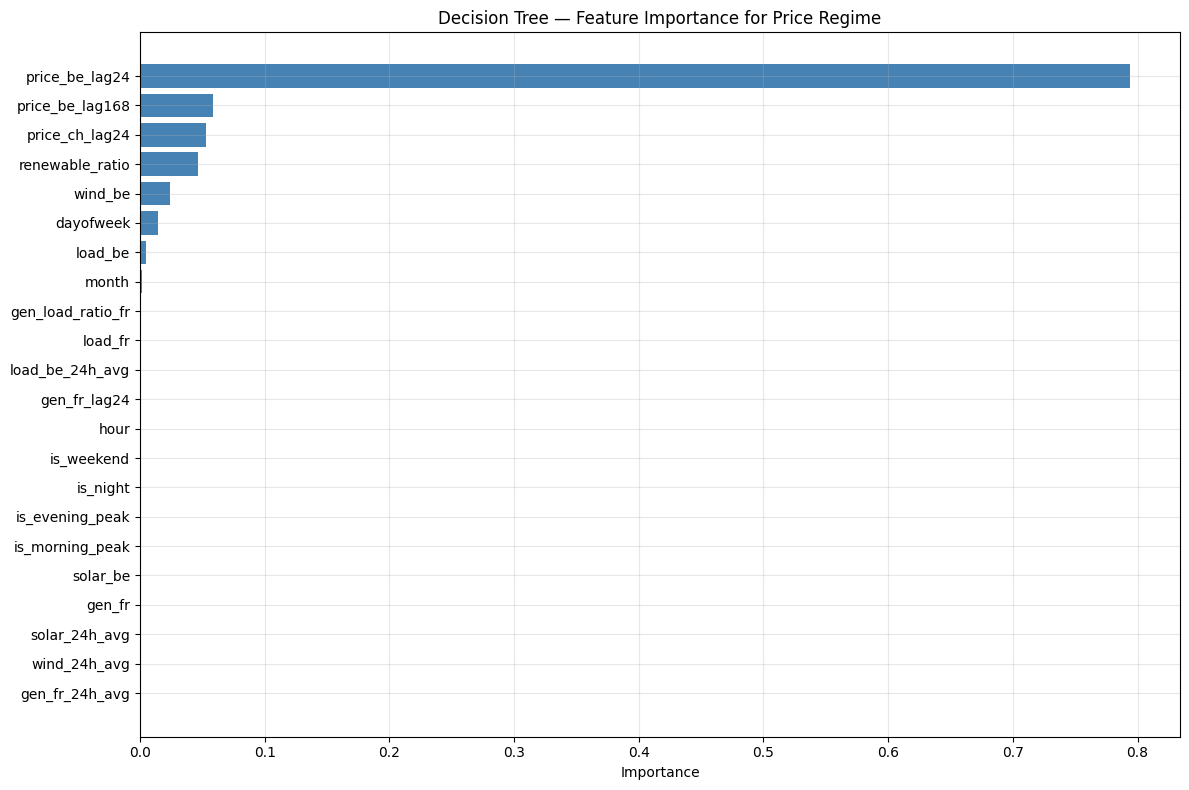


Top 10 most important features:
          Feature  Importance
   price_be_lag24    0.794342
  price_be_lag168    0.058379
   price_ch_lag24    0.053188
  renewable_ratio    0.046632
          wind_be    0.023715
        dayofweek    0.014334
          load_be    0.004572
            month    0.001576
gen_load_ratio_fr    0.000948
          load_fr    0.000918


In [134]:
feature_names = list(features_df.columns)

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': tree_router.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='steelblue')
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importance for Price Regime')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

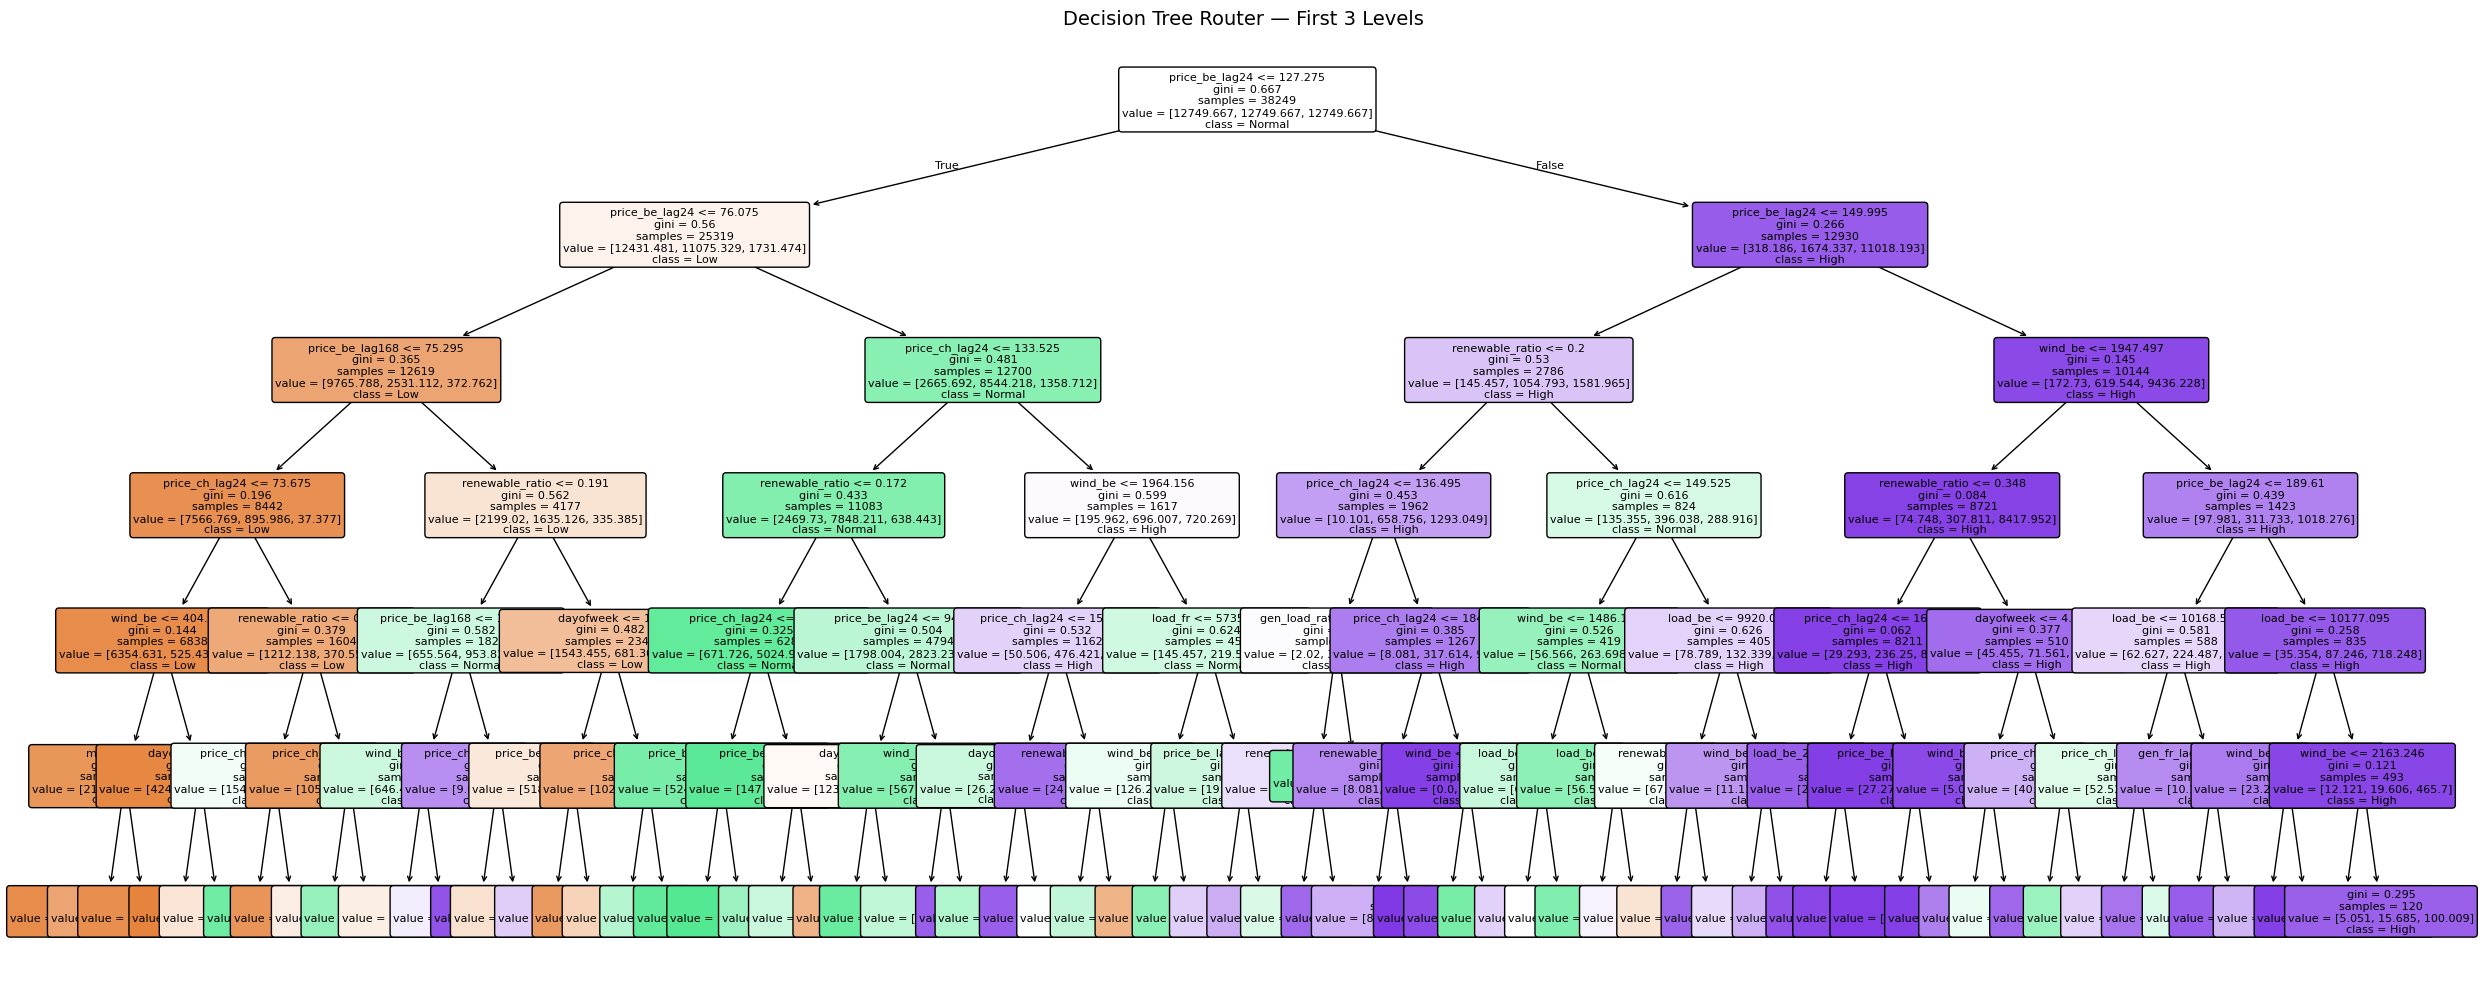

In [135]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))
plot_tree(
    tree_router,
    feature_names=feature_names,
    class_names=['Low', 'Normal', 'High'],
    filled=True,
    rounded=True,
    fontsize=8,
    # max_depth=3        # show first 3 levels for readability
)
plt.title('Decision Tree Router — First 3 Levels', fontsize=14)
plt.tight_layout()
plt.show()

In [136]:
#Better tree visualizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from supertree import SuperTree # <- import supertree :)


# Initialize supertree
super_tree = SuperTree(tree_router, X_train, y_train, feature_names, ['Low', 'Normal', 'High'])

# show tree in your notebook
super_tree.show_tree()